In [34]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import pyreadstat
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
data_path = Path(r"C:\dev\projects\BSU_DA\Annual 2005-2011_START.sav")
data, _ = pyreadstat.read_sav(data_path)

In [3]:
data.head()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,NaN,0.202055,0.165019,0.399033,0.799019,...,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,NaN,0.089377,0.220648,0.000000,0.933519,...,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,NaN,0.235739,0.508929,0.888889,0.779049,...,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,NaN,0.059439,0.030030,0.011111,0.942010,...,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,NaN,0.135491,0.886686,0.489796,0.887341,...,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2695 entries, 0 to 2694
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cреднеспис.числ.работн  2695 non-null   float64
 1   k1                      2695 non-null   float64
 2   k2                      2695 non-null   float64
 3   k3                      2695 non-null   float64
 4   k4                      2695 non-null   float64
 5   k4_new                  1540 non-null   float64
 6   k5                      2695 non-null   float64
 7   k6                      2695 non-null   float64
 8   k7                      2695 non-null   float64
 9   k8                      2695 non-null   float64
 10  k9                      2695 non-null   float64
 11  k10                     2695 non-null   float64
 12  k11                     2695 non-null   float64
 13  k12                     2695 non-null   float64
 14  k13                     2695 non-null   

In [5]:
data.describe()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,1540.000000,2695.000000,2695.000000,2695.000000,2695.000000,...,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1220.773284,2.002089,0.238018,0.825098,0.038115,0.335777,0.346330,0.238031,0.174212,0.655964,...,1.351127,1.201444,9.944428,13.504512,2.149889,201.286497,0.054974,0.079206,0.065179,8.000000
std,2556.406482,1.690052,0.517697,0.918292,0.625155,0.360196,0.198008,0.213094,0.223266,0.195774,...,0.596442,0.700291,7.636115,13.384226,2.817287,2260.459197,0.110704,0.094002,0.146802,2.000371
min,10.000000,0.248322,0.000000,0.008329,-4.569874,-2.599123,0.009944,0.000000,0.000000,0.053766,...,0.230067,0.033180,0.220451,0.347459,0.000000,0.447730,-0.975133,-0.321271,-2.670820,5.000000
25%,229.500000,1.097990,0.017088,0.317674,-0.181377,0.154884,0.185165,0.062932,0.001073,0.522272,...,1.071357,0.672567,4.598417,5.980288,0.734275,10.060489,0.023797,0.017260,0.004226,6.000000
50%,473.000000,1.473859,0.055551,0.538349,0.148620,0.367201,0.319908,0.185185,0.075676,0.681890,...,1.180362,1.106136,8.169934,9.851228,1.235572,20.099094,0.059466,0.056022,0.044154,8.000000
75%,1128.500000,2.238232,0.211538,0.941372,0.422199,0.573384,0.479741,0.361182,0.268773,0.817227,...,1.356088,1.591163,13.316773,16.690873,2.384732,48.951216,0.103877,0.123064,0.119201,10.000000
max,28650.000000,18.020148,7.029135,11.187699,0.935935,0.944507,1.083702,1.000000,1.000000,0.990056,...,10.809042,4.982852,68.830441,195.041667,31.559748,104151.000000,0.860892,0.635036,0.836596,11.000000


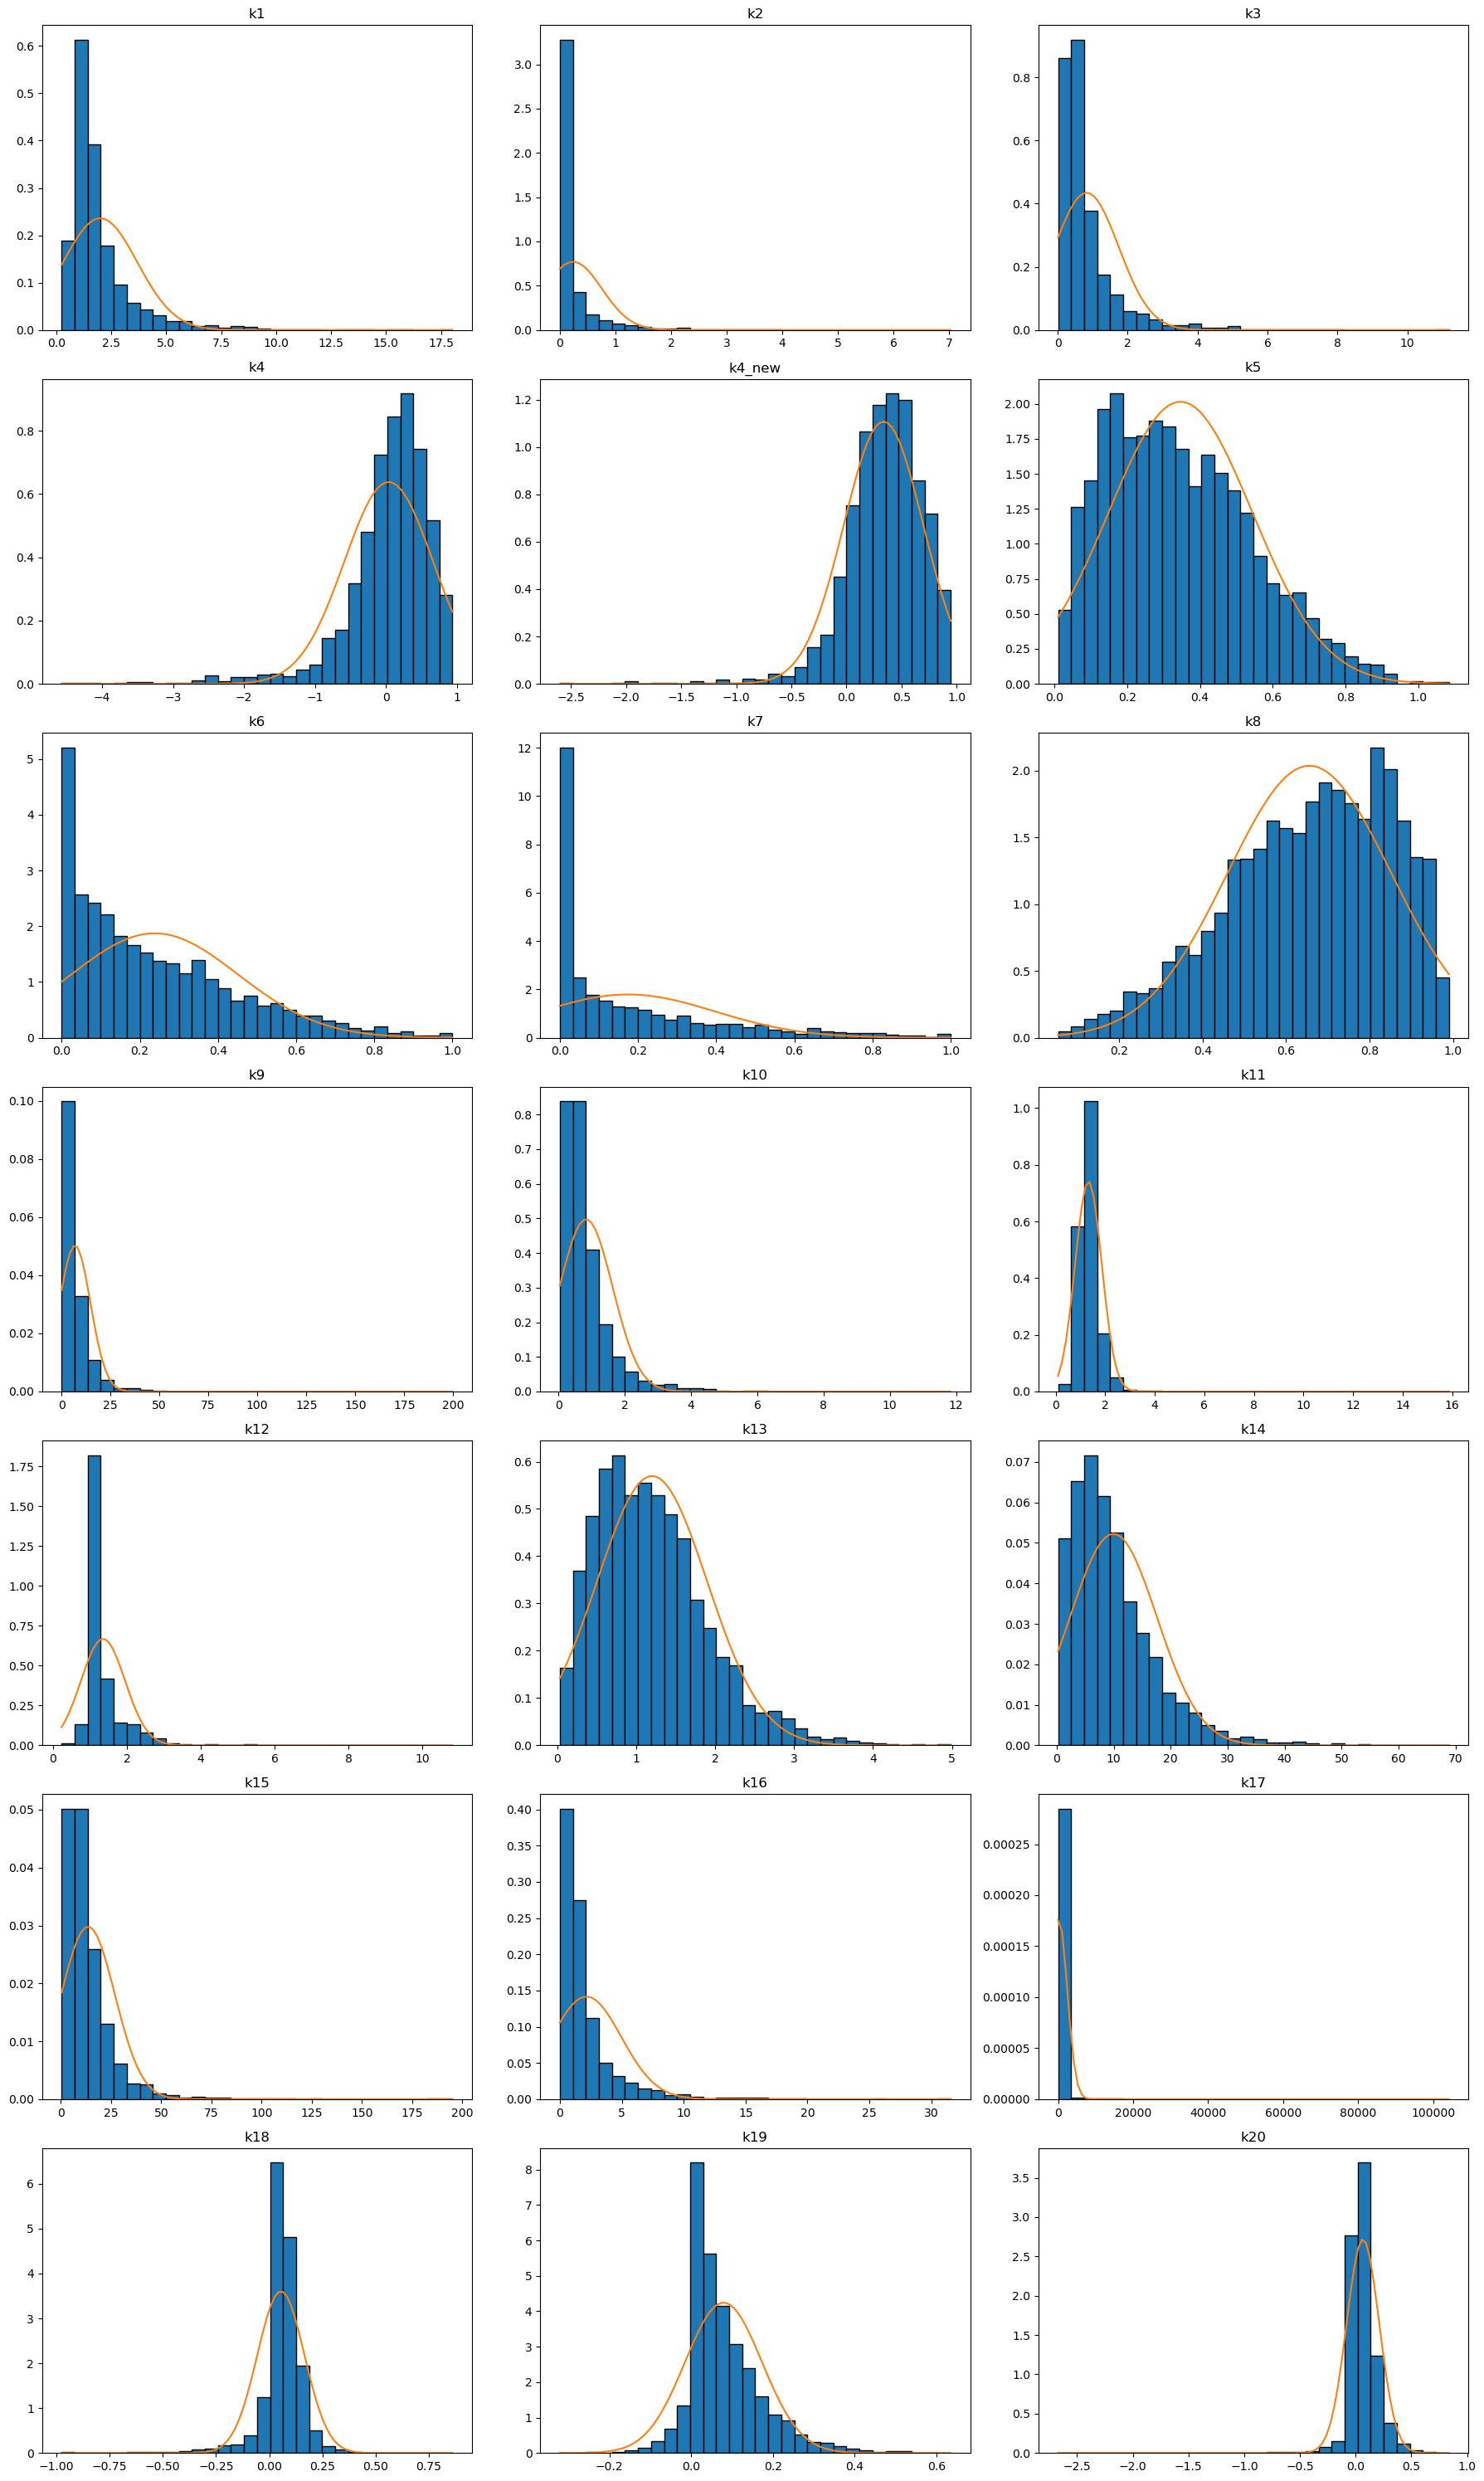

In [6]:
fig, axes = plt.subplots(7, 3, figsize = (18, 30))
axes = axes.flatten()

for i, k in enumerate(data.columns[1: -1]):
    data_tmp = data[k].dropna()
    mean_v = data_tmp.mean()
    std_v = data_tmp.std()
    
    axes[i].hist(data_tmp, bins = 30, density = True, edgecolor = 'black')
    
    x = np.linspace(data_tmp.min(), data_tmp.max(), 100)
    y = norm.pdf(x, loc = mean_v, scale = std_v)
    
    axes[i].plot(x,y)
    axes[i].set_title(k)
plt.tight_layout()
plt.show()

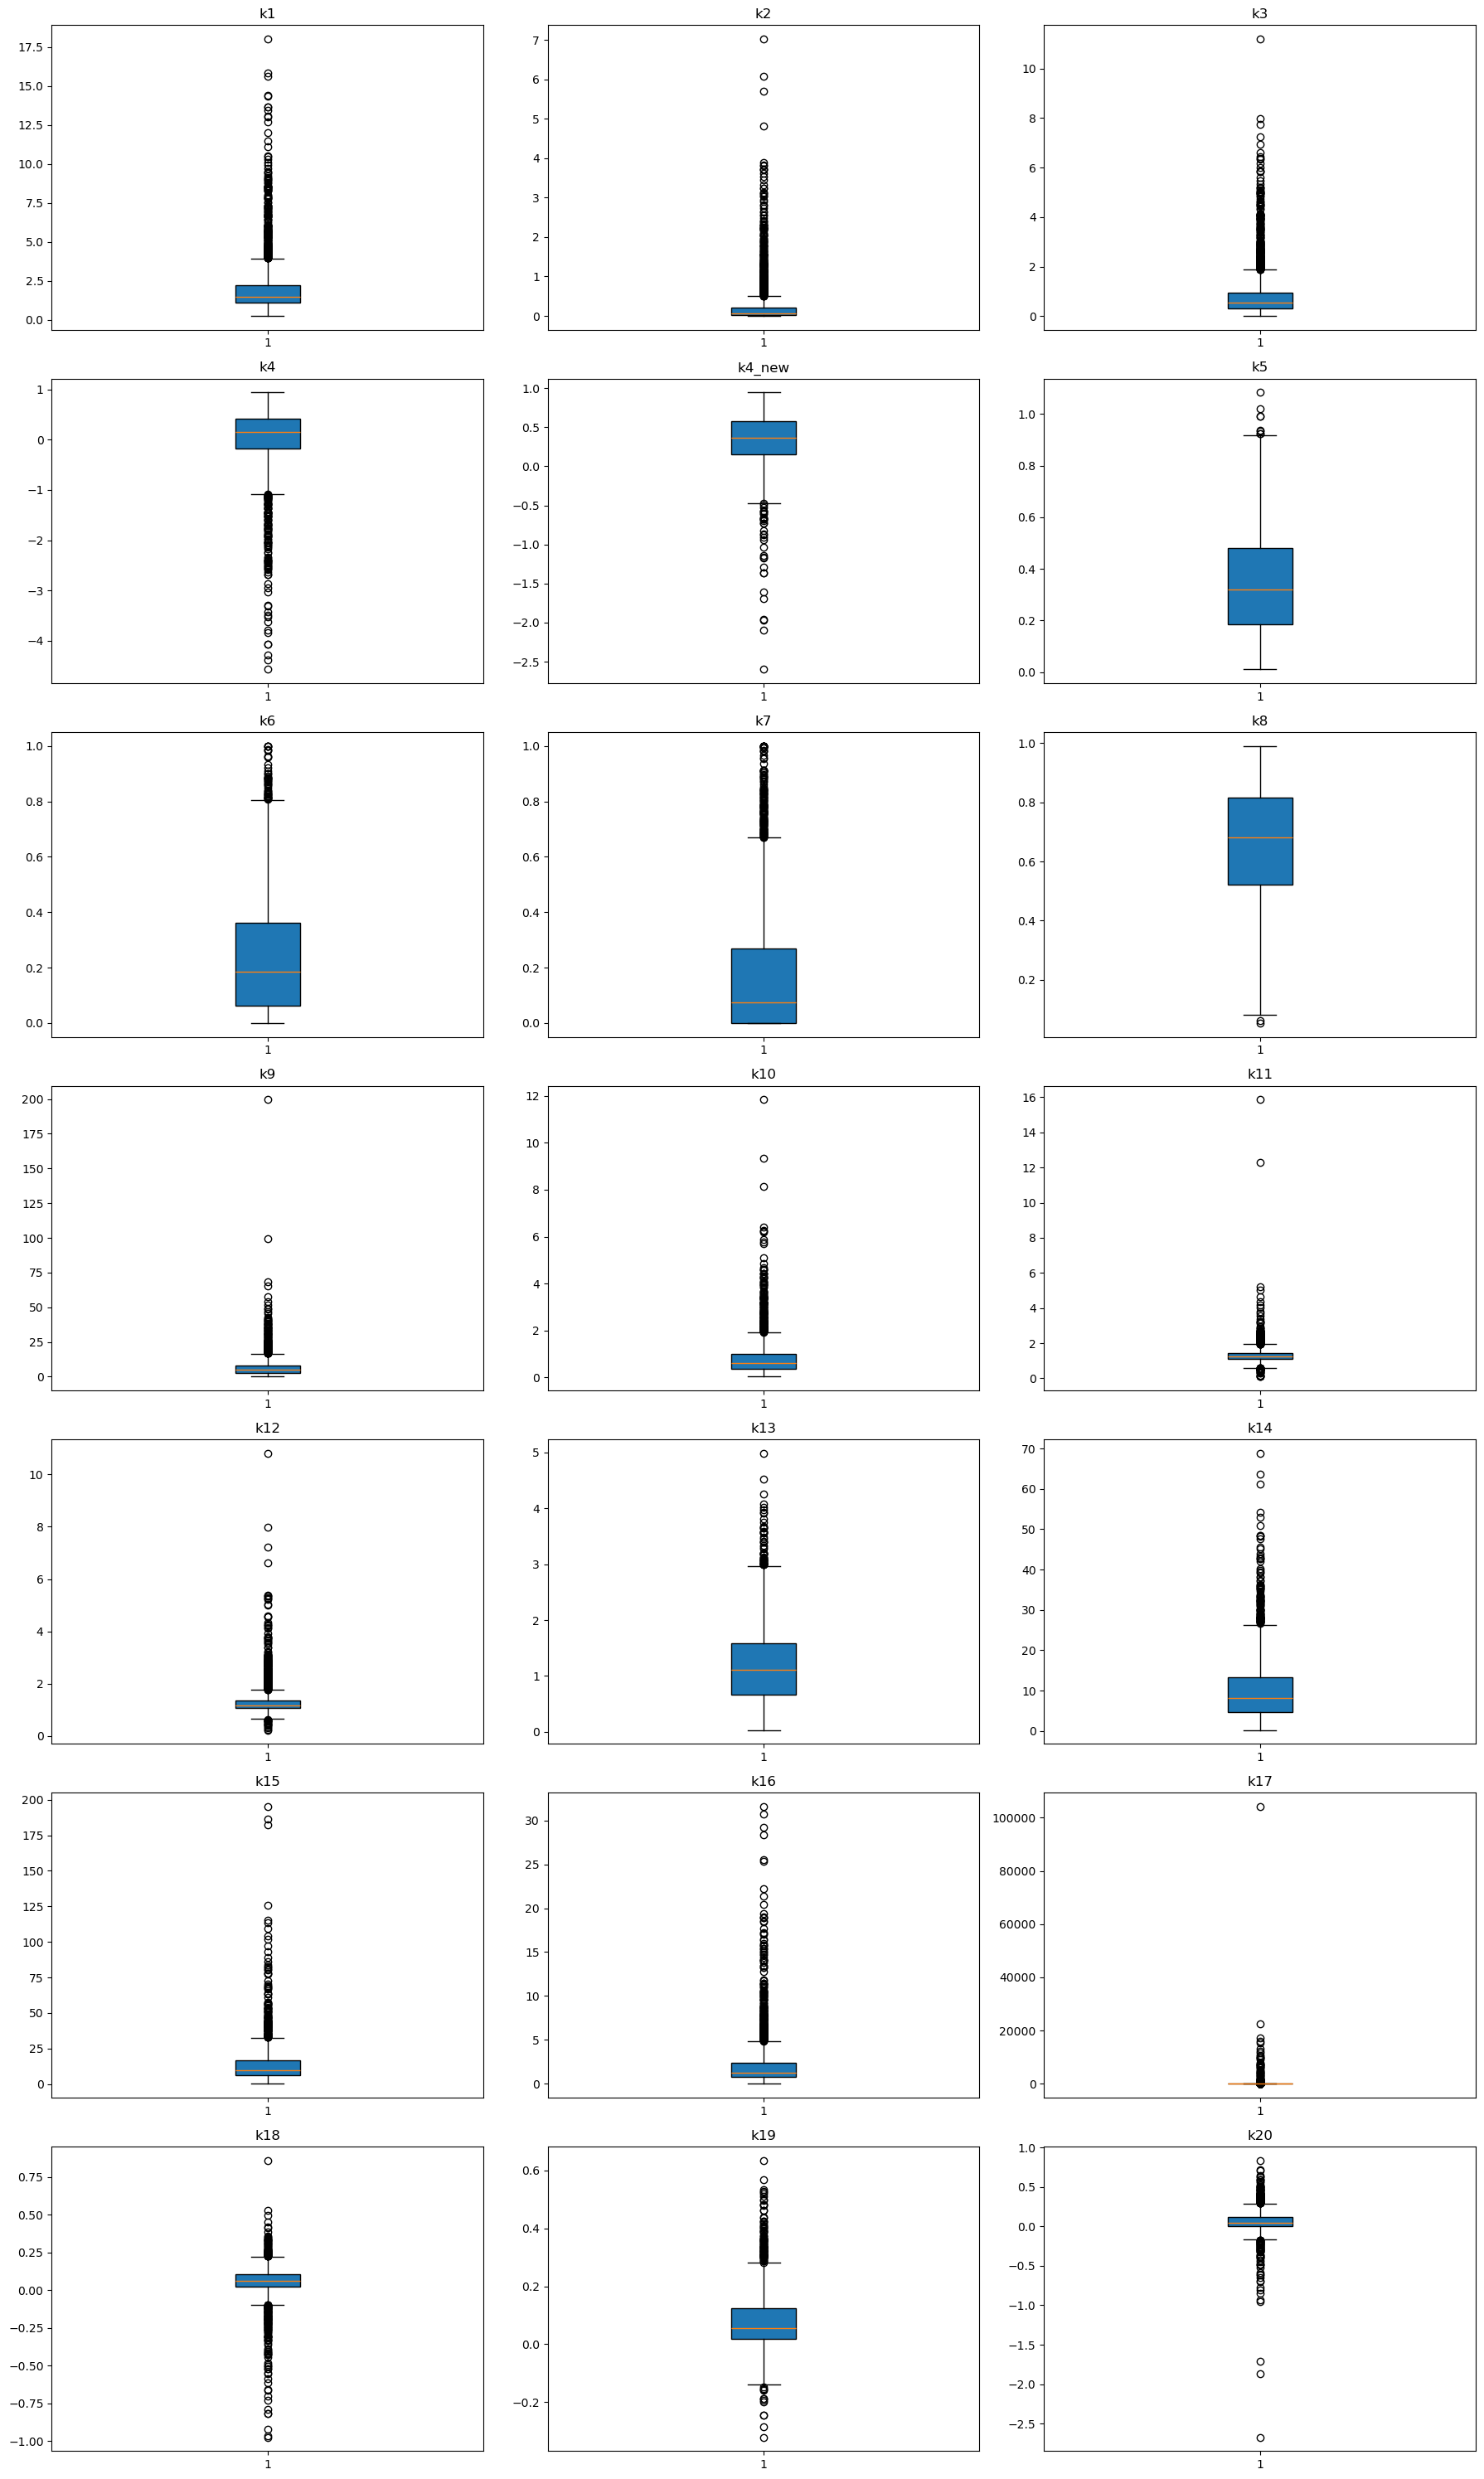

In [17]:
fig, axes = plt.subplots(7, 3, figsize = (18, 30))
axes = axes.flatten()

for i, k in enumerate(data.columns[1: -1]):
    data_tmp = data[k].dropna()

    axes[i].boxplot(data_tmp, patch_artist = True)
    axes[i].set_title(k)

plt.tight_layout()
plt.show()

In [27]:
hampel_res = {}

for k in data.columns[1: -1]:
    data_tmp = data[k].dropna()
    med_v = data_tmp.median()
    mad_v = (data_tmp - med_v).abs().median()

    for c in np.arange(0.0, 15.0, 0.1):
        low = med_v - c * mad_v
        upp = med_v + c * mad_v

        extreme = data_tmp[(data_tmp < low) | (data_tmp > upp)]
        perc = len(extreme) / len(data_tmp)
        if perc <= 0.08:
            hampel_res[k] = {
                "coeff": c,
                "percent": perc,
                "lower_bound": low,
                "upper_bound": upp,
            }
            break

In [33]:
hampel = pd.DataFrame.from_dict(hampel_res, orient = 'index')
hampel.head()

,coeff,percent,lower_bound,upper_bound
k1,5.7,0.079406,-1.288760,4.236478
k2,14.7,0.078664,-0.656800,0.767903
k3,5.4,0.079406,-0.895007,1.971705
k4,3.0,0.077180,-0.754565,1.051805
k4_new,2.5,0.079221,-0.158138,0.892540


In [39]:
censored_data = data.copy()

for k in data.columns[1: -1]:
    low = hampel_res[k].get('lower_bound')
    upp = hampel_res[k].get('upper_bound')

    censored_data[k] = censored_data[k].clip(lower = low, upper = upp)
    # print(censored_data[k].min())
    # print(censored_data[k].max())

censored_data.head()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,NaN,0.202055,0.165019,0.399033,0.799019,...,1.082798,0.655937,4.454819,3.975687,0.892446,164.627755,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,NaN,0.089377,0.220648,0.000000,0.933519,...,1.123828,0.705951,10.618881,12.295547,1.157895,164.627755,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-0.754565,NaN,0.235739,0.508929,0.560000,0.779049,...,1.185374,0.123415,0.794785,6.258929,5.519612,36.894737,-0.098819,0.010563,0.000000,5.0
3,365.0,4.236478,0.767903,1.971705,0.875862,NaN,0.059439,0.030030,0.011111,0.942010,...,1.309449,2.286511,21.382588,26.142643,0.540541,33.676983,0.171731,0.232631,0.264766,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,NaN,0.135491,0.596028,0.489796,0.887341,...,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


In [50]:
norm_arr = MinMaxScaler().fit_transform(censored_data)
norm_sk_data = pd.DataFrame(norm_arr, columns = censored_data.columns, index = censored_data.index)
norm_sk_data.describe()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,1540.000000,2695.000000,2695.000000,2695.000000,2695.000000,...,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,0.042276,0.393491,0.219450,0.361545,0.504347,0.493013,0.500224,0.382447,0.285805,0.490755,...,0.545679,0.501483,0.432715,0.420041,0.330142,0.246936,0.508140,0.550968,0.549112,0.500000
std,0.089260,0.259896,0.303998,0.277898,0.259886,0.271197,0.278140,0.318127,0.334562,0.281074,...,0.188398,0.270050,0.282670,0.276966,0.278206,0.289415,0.220882,0.219694,0.213385,0.333395
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.007664,0.213048,0.022252,0.157557,0.339064,0.297924,0.266073,0.105585,0.001916,0.270402,...,0.431120,0.283752,0.206877,0.201888,0.133030,0.058550,0.387329,0.390260,0.409506,0.166667
50%,0.016166,0.307294,0.072342,0.269953,0.534271,0.500000,0.470680,0.310699,0.135135,0.519356,...,0.486980,0.476164,0.375647,0.340628,0.223851,0.119694,0.500000,0.500000,0.500000,0.500000
75%,0.039054,0.498955,0.275474,0.475224,0.696104,0.696238,0.713388,0.605982,0.479952,0.730440,...,0.577031,0.691413,0.618856,0.585769,0.432047,0.295429,0.640288,0.689805,0.670087,0.833333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [47]:
norm_data = censored_data.copy()

for k in data.columns[1: -1]:
    data_tmp = censored_data[k].dropna()
    
    k_min = hampel_res[k].get('lower_bound')
    k_max = hampel_res[k].get('upper_bound')
    
    k_norm = (data_tmp - k_min) / (k_max - k_min)

    norm_data[k] = k_norm

In [48]:
norm_data.head()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.403809,0.503518,0.548820,0.328302,NaN,0.330954,0.475458,0.833823,0.675877,...,0.451272,0.309298,0.359411,0.340312,0.459953,1.000000,0.554562,0.497247,0.479035,5.0
1,255.0,0.591695,0.653597,0.632007,0.763404,NaN,0.169329,0.543158,0.421875,0.877837,...,0.471764,0.330484,0.592674,0.566433,0.490934,1.000000,0.678800,0.510526,0.458055,5.0
2,114.0,0.300968,0.462057,0.341906,0.000000,NaN,0.379270,0.893999,1.000000,0.645891,...,0.502503,0.083725,0.220906,0.402367,1.000000,0.558105,0.000000,0.371303,0.399927,5.0
3,365.0,1.000000,1.000000,1.000000,0.902599,NaN,0.126387,0.311175,0.433346,0.890587,...,0.564472,1.000000,1.000000,0.942774,0.418881,0.546973,0.854628,1.000000,1.000000,5.0
4,168.0,0.555295,0.464936,0.620328,0.709942,NaN,0.235475,1.000000,0.927524,0.808497,...,0.407338,0.231825,0.403838,0.317202,0.420597,0.496557,0.516877,0.414231,0.426759,5.0


In [49]:
norm_data.describe()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,1540.000000,2695.000000,2695.000000,2695.000000,2695.000000,...,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1220.773284,0.562218,0.579290,0.562730,0.471996,0.493013,0.527907,0.552044,0.587106,0.472465,...,0.557209,0.524167,0.545702,0.560219,0.568473,0.572271,0.508140,0.550968,0.549112,8.000000
std,2556.406482,0.187595,0.163852,0.190329,0.243216,0.271197,0.262733,0.230760,0.193419,0.270599,...,0.183617,0.257762,0.226370,0.210022,0.179222,0.164383,0.220882,0.219694,0.213385,2.000371
min,10.000000,0.278193,0.461008,0.315112,0.000000,0.000000,0.055392,0.274628,0.421875,0.000000,...,0.025379,0.045502,0.199172,0.241703,0.355794,0.432016,0.000000,0.000000,0.000000,5.000000
25%,229.500000,0.431972,0.473002,0.423022,0.317315,0.297924,0.306726,0.351217,0.422982,0.260324,...,0.445558,0.316343,0.364845,0.394794,0.441492,0.465271,0.387329,0.390260,0.409506,6.000000
50%,473.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,8.000000
75%,1128.500000,0.638342,0.609487,0.640587,0.651452,0.696238,0.729264,0.714190,0.699347,0.703217,...,0.587766,0.705455,0.694769,0.685890,0.634121,0.599815,0.640288,0.689805,0.670087,10.000000
max,28650.000000,1.000000,1.000000,1.000000,0.935855,1.000000,1.000000,1.000000,1.000000,0.962730,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.000000
